# Ranker Validation

Inspect scores, rationales, dealbreaker hits, and spot-check the threshold boundary.

In [1]:
import sys
sys.path.insert(0, '..')
from pathlib import Path

import json
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import select, func
from sqlalchemy.orm import Session
from src.db import get_engine, Posting

engine = get_engine(Path('../data/jobs.db'))
pd.set_option('display.max_colwidth', 100)

## Score distribution

Total scored: 1967 | Ranked: 88 | Skipped: 1879


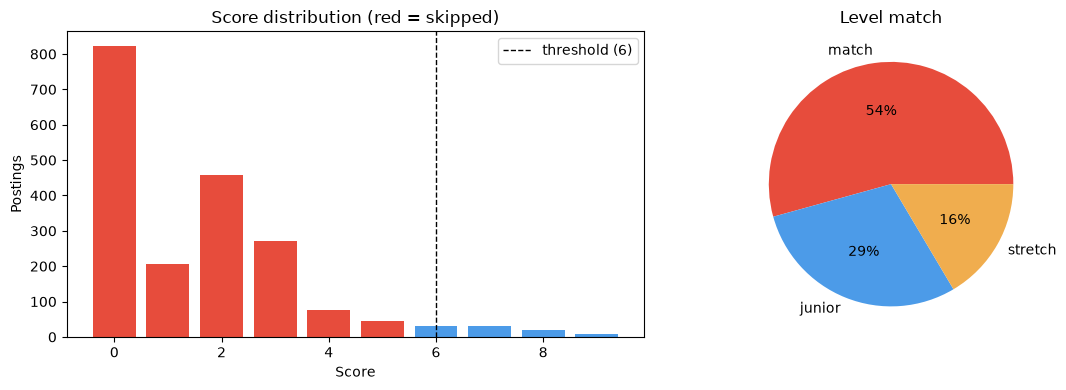

In [2]:
with Session(engine) as s:
    all_scored = s.scalars(
        select(Posting).where(Posting.relevance_score.is_not(None))
    ).all()

df = pd.DataFrame([
    {
        'id': p.id,
        'company': p.company,
        'title': p.title,
        'score': p.relevance_score,
        'level': p.level_match,
        'status': p.status,
        'rationale': p.rationale,
        'dealbreakers': json.loads(p.dealbreakers_hit or '[]'),
    }
    for p in all_scored
])

print(f'Total scored: {len(df)} | Ranked: {(df.status != "skipped").sum()} | Skipped: {(df.status == "skipped").sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score histogram
colours = ['#e74c3c' if s < 6 else '#4c9be8' for s in range(11)]
counts = df['score'].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=[colours[i] for i in counts.index])
axes[0].axvline(6, color='black', linestyle='--', linewidth=1, label='threshold (6)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Postings')
axes[0].set_title('Score distribution (red = skipped)')
axes[0].legend()

# Level match breakdown
level_counts = df['level'].value_counts()
axes[1].pie(level_counts.values, labels=level_counts.index, autopct='%1.0f%%',
            colors=['#e74c3c', '#4c9be8', '#f0ad4e'])
axes[1].set_title('Level match')

plt.tight_layout()
plt.show()

## Dealbreaker analysis

In [3]:
df_hits = df[df['dealbreakers'].apply(len) > 0].copy()
print(f'Postings with dealbreaker hits: {len(df_hits)}')

# Which dealbreakers fire most
from collections import Counter
all_hits = [h for hits in df_hits['dealbreakers'] for h in hits]
print('\nDealbreaker frequency:')
for db_id, count in Counter(all_hits).most_common():
    print(f'  {db_id}: {count}')

df_hits[['company', 'title', 'score', 'dealbreakers', 'rationale']].head(10)

Postings with dealbreaker hits: 835

Dealbreaker frequency:
  people_management: 533
  relocation_required: 280
  junior_level: 67
  heavy_sales_customer_facing: 11
  heavy_customer_facing: 3
  heavy_sales: 2
  pure_frontend: 1
  pure_marketing_no_modeling: 1


,company,title,score,dealbreakers,rationale
9,Deepmind,"Tech Strategy Director, Compute, Google DeepMind",0,[people_management],"While the stretch-level seniority is appealing, this is a strategy/business role with no ML mode..."
10,Databricks,ソリューションアーキテクト (プリセールス),0,[heavy_sales_customer_facing],"Title translates to ""Solution Architect (Pre-sales)"" — a presales/consulting role with heavy cus..."
13,Databricks,Account Executive - Federal,0,"[people_management, relocation_required]","Account Executive is a sales-focused business development role with no machine learning, data sc..."
14,Databricks,Account Executive - Public Sector,0,[people_management],"Account Executive is a sales role with no ML/modeling component, misaligned with candidate's cor..."
16,Databricks,Accounting Manager,0,[people_management],"Accounting Manager is a finance/operations role with no ML, research, or technical modeling comp..."
17,Databricks,AI Engineer - FDE (Forward Deployed Engineer),0,[relocation_required],FDE role is a customer-facing deployment engineer position fundamentally misaligned with candida...
19,Databricks,AI Engineer - FDE (Forward Deployed Engineer),0,[relocation_required],"FDE role is customer-facing generalist engineering work that lacks the modeling component, domai..."
22,Databricks,AI Engineer - FDE (Forward Deployed Engineer),0,[relocation_required],FDE (Forward Deployed Engineer) roles are customer-facing engineering positions at Databricks fo...
24,Databricks,AI Engineer - FDE (Forward Deployed Engineer),0,[relocation_required],"Forward-deployed engineering role at top-tier AI company with strong technical bar, but lacks do..."
26,Databricks,"Alliance RVP, Boston Consulting Group (BCG)",0,[people_management],"This is a business development/sales role for a Databricks partnership with BCG, not an ML engin..."


## Threshold boundary — spot-check scores 4–7

These are the postings closest to the pass/fail line. Worth reviewing manually.

In [4]:
boundary = df[df['score'].between(4, 7)].sort_values('score', ascending=False)
boundary[['score', 'status', 'level', 'company', 'title', 'rationale']].head(20)

,score,status,level,company,title,rationale
5,7,matched,match,Deepmind,"Research Scientist, Multimodal Alignment, Safety, and Fairness",Research Scientist role at DeepMind aligns strongly with research_scientist target family and mu...
661,7,matched,match,Databricks,Staff Machine Learning Engineer,Staff ML Engineer at Databricks matches the senior IC anchor and aligns well with the ML enginee...
650,7,matched,match,Databricks,Staff Data Scientist,"Strong role-family fit (data_scientist at senior level) with Python-first ML alignment, but limi..."
677,7,matched,match,Databricks,"Staff Research Engineer, Data Agents","Strong alignment on agentic LLM systems and evaluation expertise with Staff IC level, though dat..."
662,7,matched,match,Databricks,"Staff Machine Learning Engineer, CustomerLake (ML/LLM)",Staff-level ML engineer role at top-tier company with LLM/evaluation focus aligns well with cand...
1833,7,matched,match,Cohere,"Member of Technical Staff, Modeling","Strong fit on research-to-production end-to-end ownership and Python/ML stack, though LLM/founda..."
1554,7,matched,match,Openai,"Data Scientist, Safety","Strong fit on core competencies (statistical modeling, causal inference, evaluation systems, hig..."
1641,7,matched,match,Openai,"Agent Post-Training, Frontier Evals and Environments Research","Strong fit on model evaluation, LLM reliability, and end-to-end research-to-production ownership..."
1598,7,matched,match,Openai,"RE/RS, Data Understanding - Foundations","Research-scientist-track role with strong end-to-end ownership and ML methodology fit, but domai..."
1576,7,matched,match,Openai,"Software Engineer, Cyber Frontier","Strong fit on model evaluation, safeguards, and end-to-end ownership from research to production..."


## Top-ranked postings

In [5]:
top = df[df['status'] != 'skipped'].sort_values('score', ascending=False).head(20)
top[['score', 'level', 'company', 'title', 'rationale']]

,score,level,company,title,rationale
1855,9,match,Cohere,"Senior Research Scientist, Model Evaluation",Exceptional fit: Senior Research Scientist role in LLM evaluation directly aligns with candidate...
1636,9,match,Openai,"Agent Post-Training, Context Research","Exceptional fit on core signals: end-to-end ownership (research→production), model evaluation/ev..."
1610,9,match,Openai,"Agent Post-Training, Computer Use Research","Exceptional fit: LLM eval infrastructure, agentic systems, and end-to-end model training ownersh..."
1847,9,match,Cohere,"Senior Research Engineer, Model Evaluation","Direct hero-artifact alignment (deterministic eval harnesses, LLM evaluation methodology) combin..."
1662,9,match,Openai,Agent Post-Training Research,"Perfect domain fit for agentic LLM systems, model evaluation, and end-to-end research→production..."
1892,9,match,Cohere,"Senior Member of Technical Staff, Safety and Security for Agents","Exceptional fit on LLM evaluation, safety/reliability, and agent systems—core hero artifacts—wit..."
1265,9,match,Openai,"Researcher, Alignment Science","Exceptional domain fit across model evaluation, LLM reliability, end-to-end research-to-deployme..."
1121,8,match,Openai,Research Scientist,Strong research scientist fit with emphasis on autonomous research agenda ownership and publicat...
1418,8,match,Openai,"Applied AI Engineer, Codex Core Agent","Strong fit on LLM eval, agent reliability, end-to-end ownership, and Python ML stack; core Codex..."
1511,8,match,Openai,"Researcher, Alignment Training","Strong fit across model evaluation, end-to-end research-to-production ownership, and experimenta..."


## Spot-check a specific posting

Change `posting_id` to inspect any row in detail.

In [6]:
posting_id = df.sort_values('score', ascending=False).iloc[0]['id']  # default: highest-scored

with Session(engine) as s:
    p = s.get(Posting, int(posting_id))

print(f'ID:          {p.id}')
print(f'Company:     {p.company}')
print(f'Title:       {p.title}')
print(f'Location:    {p.location}')
print(f'Score:       {p.relevance_score}')
print(f'Level:       {p.level_match}')
print(f'Status:      {p.status}')
print(f'Dealbreakers: {json.loads(p.dealbreakers_hit or "[]")}')
print(f'Rationale:   {p.rationale}')
print(f'URL:         {p.url}')
print(f'\n--- Description (first 1000 chars) ---')
print(p.description[:1000])

ID:          1893
Company:     Cohere
Title:       Senior Member of Technical Staff, Safety and Security for Agents
Location:    London
Score:       9
Level:       match
Status:      matched
Dealbreakers: []
Rationale:   Exceptional fit on LLM evaluation, safety/reliability, and agent systems—core hero artifacts—with strong software engineering and experimental design emphasis that aligns perfectly with candidate's production ML and eval harness expertise.
URL:         https://jobs.ashbyhq.com/cohere/1f7cc5e6-5f31-40d8-ad49-fe22c98a3ea4

--- Description (first 1000 chars) ---
<p style="min-height:1.5em"><strong>Who are we?</strong></p><p style="min-height:1.5em">Cohere is the leading security-first enterprise AI company.  We build cutting-edge foundation AI models and end-to-end products that are designed to solve real-world business problems.</p><p style="min-height:1.5em">We’re training and deploying frontier models for enterprises who are building AI systems. We believe that our wor